## GPA Prediction from Student Lifestyle Data
## Exploratory Data Analysis and Data Enrichment

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("student_lifestyle_dataset.csv")
df.head()
df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


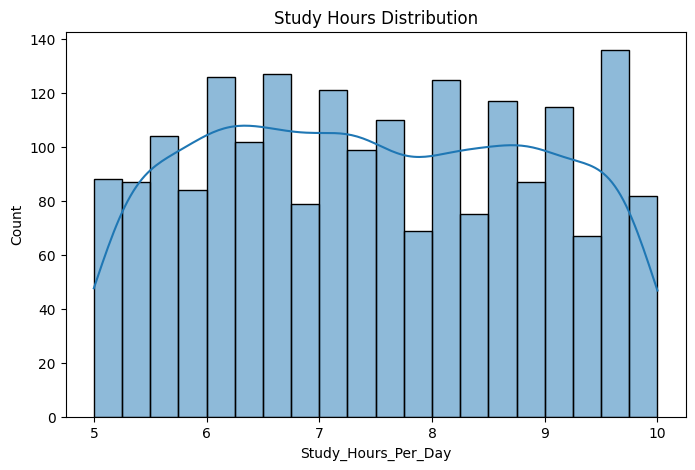

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Study_Hours_Per_Day"], bins=20, kde=True)
plt.title("Study Hours Distribution")
plt.show()

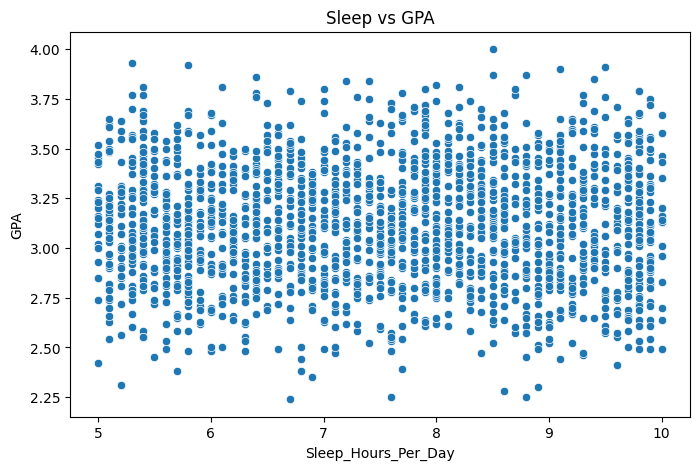

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Sleep_Hours_Per_Day", y="GPA", data=df)
plt.title("Sleep vs GPA")
plt.show()

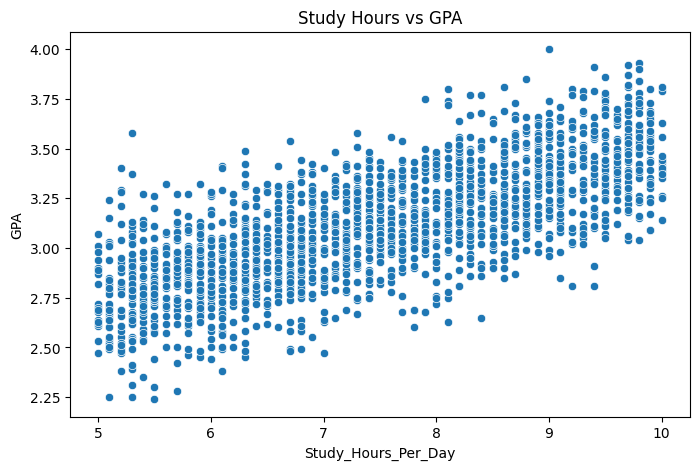

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Study_Hours_Per_Day", y="GPA", data=df)
plt.title("Study Hours vs GPA")
plt.show()

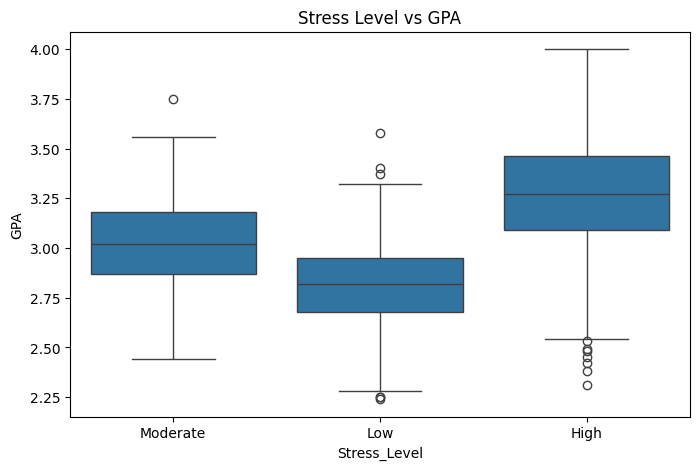

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Stress_Level", y="GPA", data=df)
plt.title("Stress Level vs GPA")
plt.show()

In [ ]:
stress_map = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

df["Stress_Level_Numeric"] = df["Stress_Level"].map(stress_map)

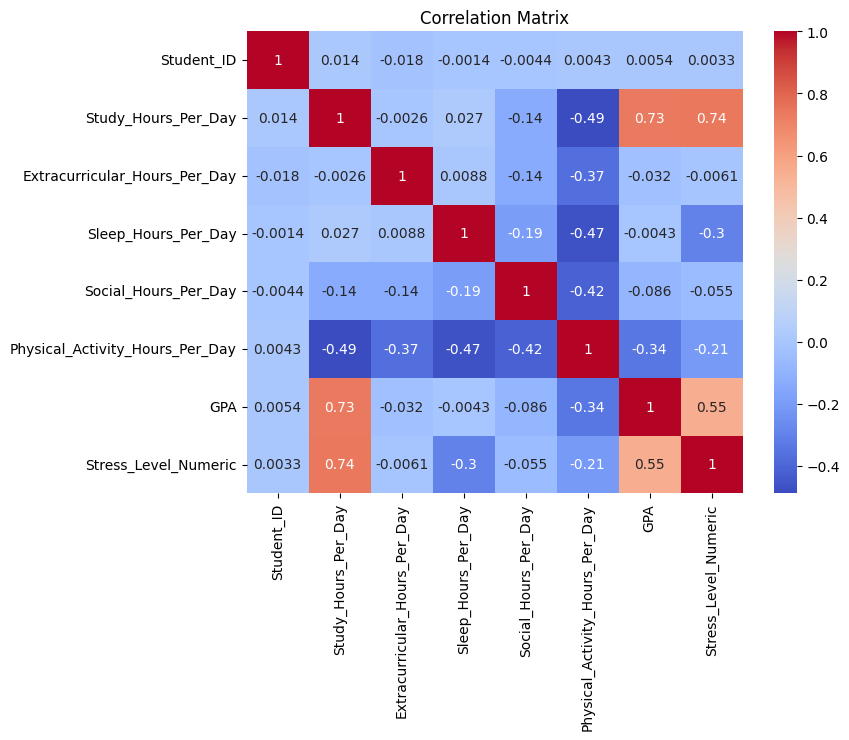

In [ ]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

*  GPA shows positive correlation with study hours.
*  Sleep has a mild positive relationship with GPA.
*  Stress level tends to negatively affect GPA.





In [7]:
student = pd.read_csv("student-mat.csv", sep=";")
student.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [8]:
student.shape

(395, 33)

In [9]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [10]:
student.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [11]:
student.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


The Student Performance dataset contains individual-level student information.
The target variable is G3, which represents the final grade.
Since the dataset includes study time, absences, social activities, family background, and previous grades, it is suitable for GPA/final grade prediction.

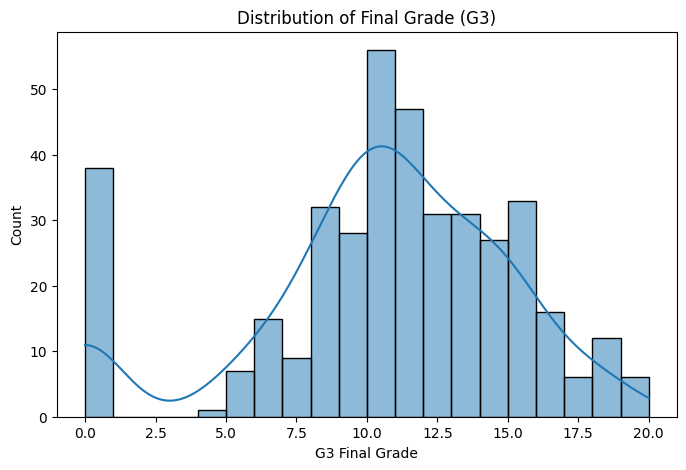

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(student["G3"], bins=20, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("G3 Final Grade")
plt.ylabel("Count")
plt.show()

In [13]:
numeric_cols = student.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

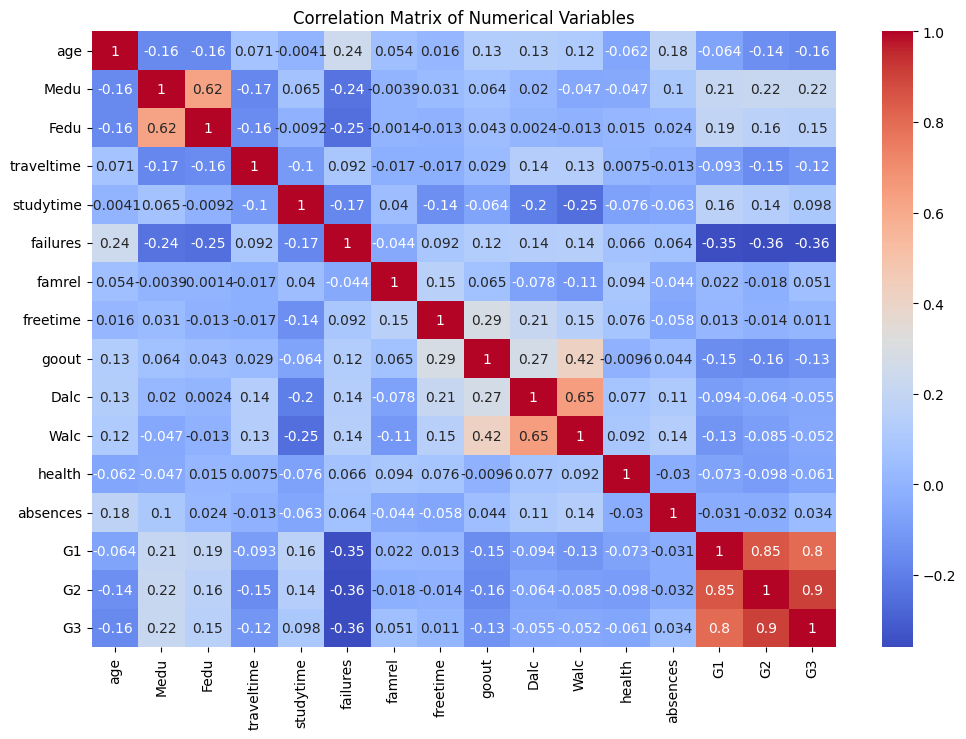

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(student[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [15]:
student[numeric_cols].corr()["G3"].sort_values(ascending=False)

,G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
Walc,-0.051939


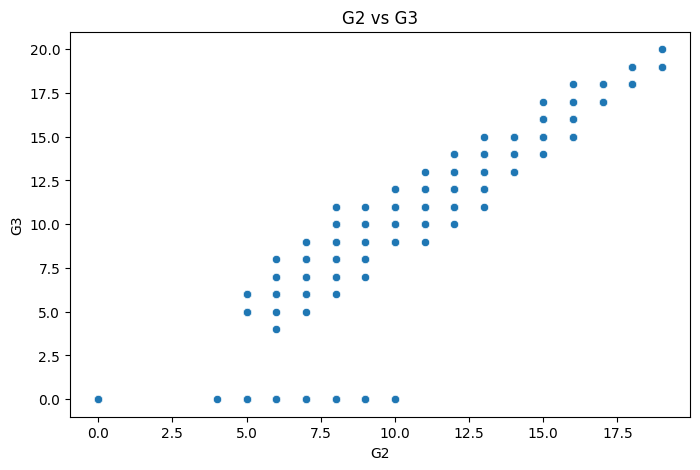

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="G2", y="G3", data=student)
plt.title("G2 vs G3")
plt.show()

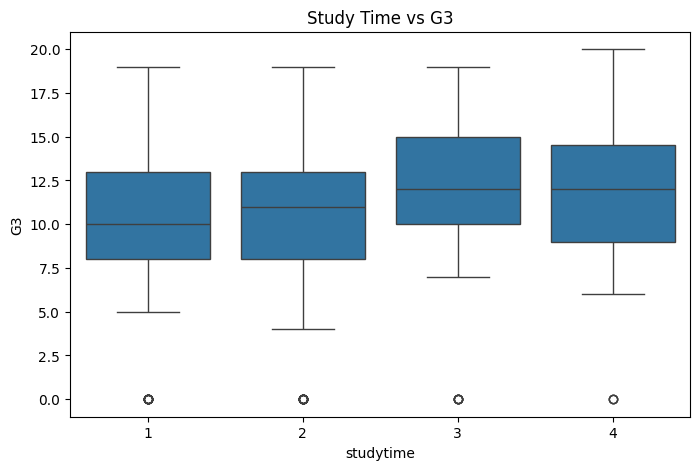

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="studytime", y="G3", data=student)
plt.title("Study Time vs G3")
plt.show()

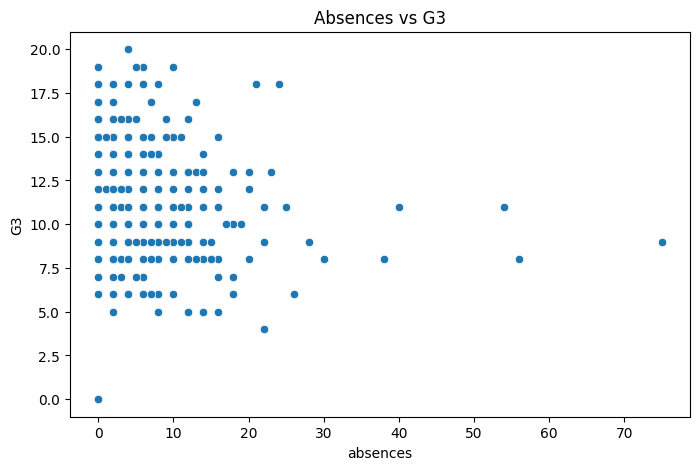

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="absences", y="G3", data=student)
plt.title("Absences vs G3")
plt.show()

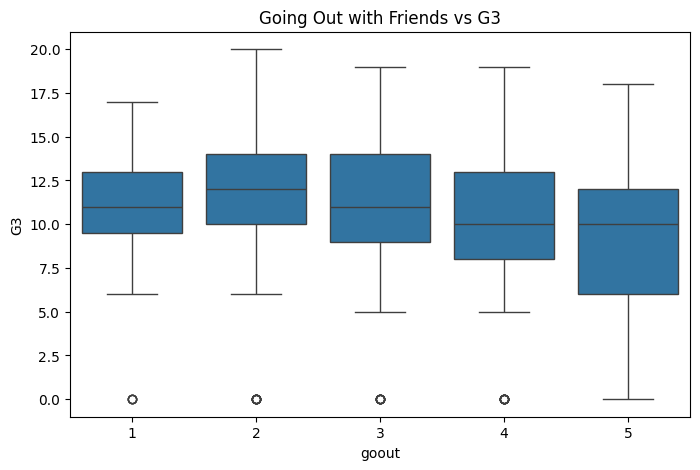

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="goout", y="G3", data=student)
plt.title("Going Out with Friends vs G3")
plt.show()

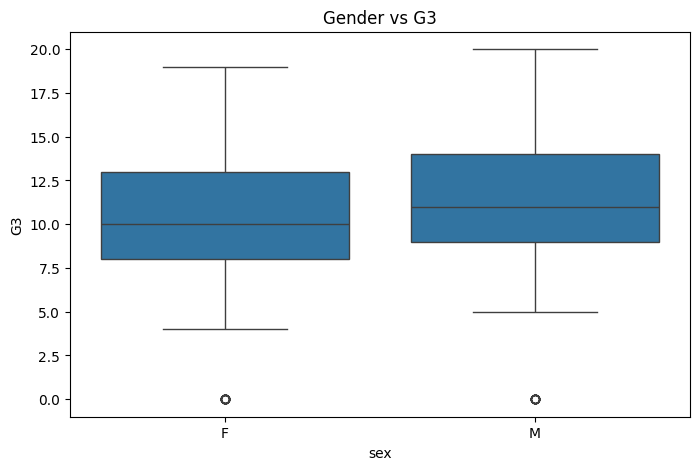

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x="sex", y="G3", data=student)
plt.title("Gender vs G3")
plt.show()

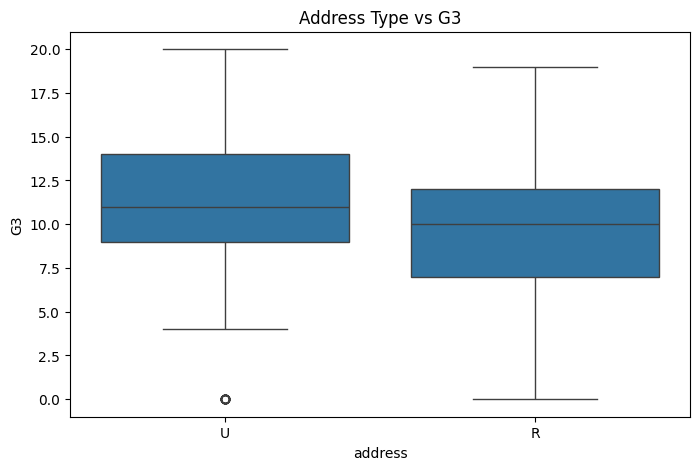

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="address", y="G3", data=student)
plt.title("Address Type vs G3")
plt.show()

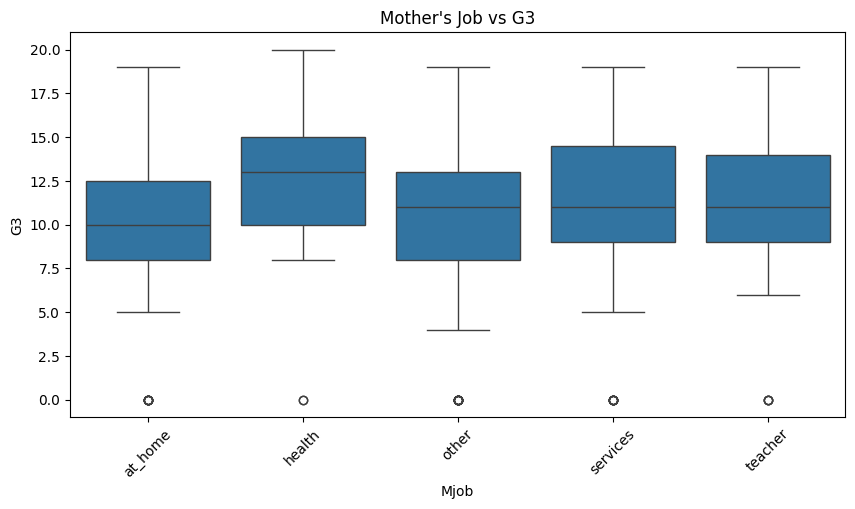

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Mjob", y="G3", data=student)
plt.title("Mother's Job vs G3")
plt.xticks(rotation=45)
plt.show()

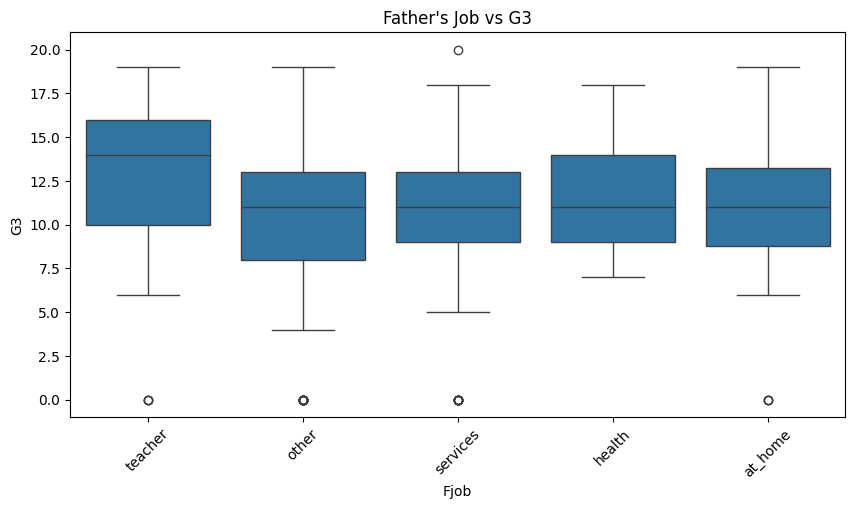

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Fjob", y="G3", data=student)
plt.title("Father's Job vs G3")
plt.xticks(rotation=45)
plt.show()

## Overall Insights

* G1 and G2 show strong positive correlation with G3.
* Study time is positively related to final grades.
* Absences and past failures negatively affect performance.
* Social activities and alcohol consumption show weak negative trends.
* Family background variables (Mjob, Fjob, education) show some variation but no strong patterns.

# Hypothesis Testing

## Datasets Used for Hypothesis Testing

In this project, two datasets are used to analyze factors affecting academic performance.

The first dataset focuses on students' daily lifestyle habits and GPA.
It includes variables such as study hours, sleep hours, social hours, physical activity, extracurricular activities, stress level, and GPA.
In this section, hypothesis tests are conducted to examine whether these lifestyle-related variables have statistically significant relationships with GPA.

The second dataset is the Student Performance dataset, which includes detailed information about students such as study time, absences, social behavior, family background, and their final grade (G3). This dataset is used to analyze how different factors relate to final academic performance.


Both datasets are analyzed separately without merging, since they represent different groups of students. Hypothesis testing is applied to each dataset to evaluate whether the observed relationships are statistically significant.

#### Hypothesis 1: Study Hours vs GPA

H0: There is no relationship between study hours and GPA  
H1: There is a significant relationship between study hours and GPA

In [31]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["Study_Hours_Per_Day"], df["GPA"])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.7344679806560517
p-value: 0.0


The correlation between study hours and GPA is strong and positive.
Since the p-value is less than 0.05, we reject the null hypothesis.
This indicates that study hours have a statistically significant and strong positive effect on GPA.

#### Hypothesis 2: Sleep vs GPA

H0: There is no relationship between sleep hours and GPA  
H1: There is a significant relationship between sleep hours and GPA

In [32]:
corr, p_value = pearsonr(df["Sleep_Hours_Per_Day"], df["GPA"])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: -0.0042784409489437705
p-value: 0.8483540570887701


The correlation between sleep hours and GPA is extremely weak (close to zero).
Since the p-value is much greater than 0.05, we fail to reject the null hypothesis.
This indicates that sleep does not have a statistically significant effect on GPA in this dataset.

#### Hypothesis 3: Stress Level vs GPA

H0: GPA does not differ across stress levels  
H1: GPA differs significantly across stress levels

In [33]:
from scipy.stats import f_oneway

low = df[df["Stress_Level"] == "Low"]["GPA"]
moderate = df[df["Stress_Level"] == "Moderate"]["GPA"]
high = df[df["Stress_Level"] == "High"]["GPA"]

f_stat, p_value = f_oneway(low, moderate, high)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 434.88819227855345
p-value: 1.6587091705309335e-157


Since the p-value is extremely small (close to zero), we reject the null hypothesis.
This indicates that stress level has a statistically significant effect on GPA.

The large F-statistic suggests that the differences in GPA across stress levels are substantial.

#### Hypothesis 1: Absences vs Final Grade (G3)

H0: There is no relationship between absences and final grade (G3)  
H1: There is a significant relationship between absences and final grade (G3)

In [25]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(student["absences"], student["G3"])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.034247316150069325
p-value: 0.49733179554352747


The correlation between absences and G3 is very weak (close to zero).
Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
This indicates that absences do not have a statistically significant effect on final grades in this dataset.

#### Hypothesis 2: Gender vs Final Grade (G3)

H0: There is no difference in G3 between male and female students  
H1: There is a significant difference in G3 between male and female students

In [26]:
from scipy.stats import ttest_ind

male = student[student["sex"] == "M"]["G3"]
female = student[student["sex"] == "F"]["G3"]

t_stat, p_value = ttest_ind(male, female)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 2.061992815503971
p-value: 0.039865332341527636


In [27]:
print("Male mean:", male.mean())
print("Female mean:", female.mean())

Male mean: 10.914438502673796
Female mean: 9.966346153846153


Since the p-value is less than 0.05, we reject the null hypothesis.
This indicates that there is a statistically significant difference in final grades (G3) between male and female students.

Additionally, male students have a higher average G3 compared to female students in this dataset.

However, the difference in mean values is relatively small.

#### Hypothesis 3: Study Time vs Final Grade (G3)

H0: Study time has no effect on final grade (G3)  
H1: Study time has a significant effect on final grade (G3)

In [28]:
from scipy.stats import f_oneway

group1 = student[student["studytime"] == 1]["G3"]
group2 = student[student["studytime"] == 2]["G3"]
group3 = student[student["studytime"] == 3]["G3"]
group4 = student[student["studytime"] == 4]["G3"]

f_stat, p_value = f_oneway(group1, group2, group3, group4)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1.7278351054436032
p-value: 0.1607228096836598


Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
This indicates that study time does not have a statistically significant effect on final grade (G3).

Although EDA suggested a positive relationship, this result shows that the effect is not statistically significant.

## Comparative Insights from Both Datasets

While some variables appeared to have relationships during EDA, hypothesis testing showed that not all of them are statistically significant.

The hypothesis testing results from the two datasets reveal important differences in how academic performance is influenced.

In the Student Performance dataset, most variables such as study time and absences did not show statistically significant effects on final grades, while gender showed a small but significant difference. This suggests that academic performance in this dataset is more strongly driven by prior grades and possibly unobserved factors.

In contrast, the Student Lifestyle dataset shows much stronger relationships between daily habits and academic performance. Study hours have a strong positive effect on GPA, and stress level has a very strong and statistically significant impact. However, sleep does not appear to have a meaningful effect.

These differences highlight that while academic history (such as previous grades) is a strong predictor in structured school datasets, lifestyle factors such as study habits and stress play a more dominant role when directly measured.

Overall, combining insights from both datasets provides a more comprehensive understanding of academic performance, showing that both prior achievement and lifestyle factors are important, but their relative impact may vary depending on how the data is collected.

This also demonstrates the importance of using multiple datasets to capture different dimensions of academic performance.